### Step 1: Loading the Dataset and Basic Inspection
In this step, we import the necessary libraries (Pandas, NumPy) and load the Parkinson's Voice dataset from a public source. We will check the shape of the dataset, look at the first few rows, and verify if there are any missing values.

In [ ]:
import pandas as pd

# Direct file read
df = pd.read_csv('parkinsons[1].csv')

# Check shape and missing values
print("Dataset Shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
display(df.head())

Dataset Shape: (195, 24)
Total missing values: 0


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


### Step 2: Feature Selection, Scaling, and Train-Test Split
In this step, we separate the features (X) from the target variable (`status`). We apply StandardScaler to normalize the feature values so that the Artificial Neural Network (ANN) can train efficiently. Finally, we split the dataset into training (80%) and testing (20%) sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target label (y)
# 'name' is just an identifier, and 'status' is our target (1 = Parkinson's, 0 = Healthy)
X = df.drop(columns=['name', 'status'])
y = df['status']

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler (crucial for ANNs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train scaled shape:", X_train_scaled.shape)
print("X_test scaled shape:", X_test_scaled.shape)
print("\nStep 2 completed successfully!")

X_train scaled shape: (156, 22)
X_test scaled shape: (39, 22)

Step 2 completed successfully!


### Step 3: ANN Model Architecture and Training
In this step, we build a Sequential Artificial Neural Network (ANN) using TensorFlow/Keras. We use Dense layers with ReLU activation for feature learning, and a final Dense layer with a Sigmoid activation function for binary classification (Parkinson's vs Healthy). We also compile the model using Adam optimizer and binary crossentropy loss.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Define the ANN Architecture
model = Sequential([
    # Input layer and 1st Hidden Layer with 32 neurons and ReLU activation
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Dropout layer to prevent overfitting on small data

    # 2nd Hidden Layer with 16 neurons
    Dense(16, activation='relu'),

    # Output Layer with 1 neuron and Sigmoid activation for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

# 2. Compile the Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Train the Model
history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.1,
                    verbose=1)

print("\nANN Model Training completed successfully!")

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3857 - loss: 0.8946 - val_accuracy: 0.5000 - val_loss: 0.8235
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4643 - loss: 0.7207 - val_accuracy: 0.6875 - val_loss: 0.6524
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6643 - loss: 0.6245 - val_accuracy: 0.7500 - val_loss: 0.5572
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7357 - loss: 0.5732 - val_accuracy: 0.8125 - val_loss: 0.4986
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8143 - loss: 0.5276 - val_accuracy: 0.7500 - val_loss: 0.4622
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7643 - loss: 0.5150 - val_accuracy: 0.8125 - val_loss: 0.4338
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8286 - loss: 0.4661 - val_accuracy: 0.8125 - val_loss: 0.4118
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8500 - loss: 0.4331 - val_accuracy: 0.8125 - val_loss: 0.3881
Epoch 9/50
9/9 ━━

### Step 4: Model Evaluation and Performance Metrics
In this step, we evaluate our trained ANN model on the unseen test dataset. We generate predictions, convert the sigmoid probabilities into binary classes (0 or 1), and evaluate the model using Accuracy, Precision, Recall, and a Confusion Matrix to thoroughly analyze performance.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Test Accuracy: 87.18%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.89      0.97      0.93        32

    accuracy                           0.87        39
   macro avg       0.82      0.70      0.74        39
weighted avg       0.86      0.87      0.86        39



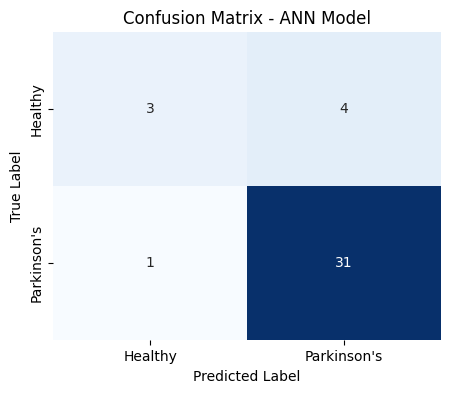

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict probabilities on test data
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to binary classes (0 or 1) using 0.5 threshold
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# 2. Calculate Evaluation Metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy', "Parkinson's"],
            yticklabels=['Healthy', "Parkinson's"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ANN Model')
plt.show()

### Step 3.1: Handling Class Imbalance with Class Weights

**Observation from Baseline Evaluation:**
The initial evaluation of our ANN model showed high performance on the majority class (Parkinson's, Class 1), but a lower F1-score on the minority class (Healthy, Class 0) due to the natural data distribution of the UCI Parkinson's dataset.

**Optimization Approach:**
To address this bias and ensure fair evaluation across both classes, we compute automatic `class_weights` using `sklearn.utils.class_weight` and pass them into the training loop (`model.fit`). This applies a higher penalty for misclassifying the minority class, forcing the neural network to give equal attention to healthy voice samples.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

# 1. Calculate Class Weights automatically based on y_train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Calculated Class Weights (to handle imbalance):", class_weight_dict)

# 2. Re-initialize the ANN Model for a fresh training session with weights
balanced_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

balanced_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# 3. Train the model using class_weights
print("\nTraining the model with Class Weights...")
history_balanced = balanced_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    class_weight=class_weight_dict,  # Yeh line minority class (Healthy) ko barabar weight degi
    verbose=1
)

Calculated Class Weights (to handle imbalance): {0: np.float64(1.9024390243902438), 1: np.float64(0.6782608695652174)}

Training the model with Class Weights...
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6000 - loss: 0.7031 - val_accuracy: 0.6250 - val_loss: 0.5823
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6429 - loss: 0.6242 - val_accuracy: 0.6250 - val_loss: 0.5577
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7286 - loss: 0.5529 - val_accuracy: 0.6875 - val_loss: 0.5647
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 0.5104 - val_accuracy: 0.6875 - val_loss: 0.5872
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.4823 - val_accuracy: 0.6875 - val_loss: 0.5910
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 0.4664 - val_accuracy: 0.6875 - val_loss: 0.5958
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7143 - loss: 0.4404 - val_accuracy: 0.6875 - val_loss: 0.6057
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7429 - loss: 0.4295 - val_accuracy: 0.6875 - val_loss: 0.6013
Epoch 9/50
9/9 ━━━

### Step 4: Evaluation and Performance Analysis of the Balanced Model

**Evaluation Objective:**
After training our ANN model with class weights to resolve data imbalance, we evaluate its performance on the unseen test dataset (`X_test_scaled`).

**Metrics & Visualizations:**
* **Test Accuracy:** Measures the overall correctness of the model.
* **Classification Report (Precision, Recall, F1-Score):** To verify if the performance and detection rate of the minority class (Healthy, Class 0) have significantly improved compared to the baseline model.
* **Confusion Matrix:** A visual heatmap to clearly analyze true predictions versus misclassifications across both classes.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Balanced Model Test Accuracy: 89.74%

--- Classification Report (With Class Weights) ---
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.94      0.94      0.94        32

    accuracy                           0.90        39
   macro avg       0.83      0.83      0.83        39
weighted avg       0.90      0.90      0.90        39



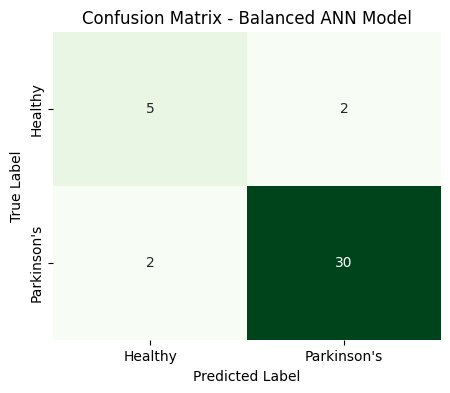

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict probabilities on test data using the balanced model
y_pred_probs_bal = balanced_model.predict(X_test_scaled)

# Convert probabilities to binary classes (0 or 1) using 0.5 threshold
y_pred_bal = (y_pred_probs_bal > 0.5).astype("int32").flatten()

# 2. Calculate Evaluation Metrics
test_accuracy_bal = accuracy_score(y_test, y_pred_bal)
print(f"Balanced Model Test Accuracy: {test_accuracy_bal * 100:.2f}%\n")

print("--- Classification Report (With Class Weights) ---")
print(classification_report(y_test, y_pred_bal))

# 3. Plot Confusion Matrix
conf_matrix_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix_bal, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Healthy', "Parkinson's"],
            yticklabels=['Healthy', "Parkinson's"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Balanced ANN Model')
plt.show()

### Step 5: Interactive Web Application Deployment (Gradio)

**Objective:**
To transform our trained Artificial Neural Network (ANN) model into a portfolio-ready and accessible product, we are deploying an interactive web interface using **Gradio**.

**Features:**
* **Clean Input Form:** Allows users to input key vocal acoustic features (such as Fundamental Frequency, Jitter, Shimmer, and HNR).
* **Automated Scaling & Inference:** Automatically scales the inputs using the saved `StandardScaler` and passes them to the optimized `balanced_model`.
* **Instant Diagnosis:** Outputs a real-time prediction indicating whether the voice sample is Healthy or indicates Parkinson's Disease, along with confidence scores.

In [12]:
import gradio as gr
import numpy as np
import pandas as pd

def predict_all_features(
    fo, fhi, flo, jitter_percent, jitter_abs, rap, ppq, ddp,
    shimmer, shimmer_apq3, shimmer_apq5, apq, dda, nhr, hnr,
    rpde, dfma, spread1, spread2, d2, ppe, loc
):
    try:
        # 1. Sabhi 22 features ki mukammal array
        input_data = np.array([[
            fo, fhi, flo, jitter_percent, jitter_abs, rap, ppq, ddp,
            shimmer, shimmer_apq3, shimmer_apq5, apq, dda, nhr, hnr,
            rpde, dfma, spread1, spread2, d2, ppe, loc
        ]])

        # 2. StandardScaler ke zariye scale karna
        input_scaled = scaler.transform(input_data)

        # 3. Balanced Model se Prediction lena (float conversion ke sath taake nan na aaye)
        pred_prob = float(balanced_model.predict(input_scaled)[0][0])

        # 4. Result return karna
        if pred_prob > 0.5:
            confidence = pred_prob * 100
            return f"⚠️ Result: Parkinson's Detected\nConfidence: {confidence:.2f}%"
        else:
            confidence = (1 - pred_prob) * 100
            return f"✅ Result: Healthy Voice Sample\nConfidence: {confidence:.2f}%"

    except Exception as e:
        return f"Error in processing: {str(e)}"

# Gradio Professional Multi-Column Layout for All Features
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🧠 Advanced Parkinson's Disease Detection System")
    gr.Markdown("Enter all the biomedical voice measurement parameters below for an accurate, full-feature AI diagnosis.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🎵 Frequency Parameters")
            fo = gr.Number(label="MDVP:Fo(Hz)", value=119.992)
            fhi = gr.Number(label="MDVP:Fhi(Hz)", value=157.302)
            flo = gr.Number(label="MDVP:Flo(Hz)", value=74.997)

        with gr.Column():
            gr.Markdown("### 🎚️ Jitter Parameters")
            jitter_percent = gr.Number(label="MDVP:Jitter(%)", value=0.00784)
            jitter_abs = gr.Number(label="MDVP:Jitter(Abs)", value=0.00007)
            rap = gr.Number(label="MDVP:RAP", value=0.00370)
            ppq = gr.Number(label="MDVP:PPQ", value=0.00554)
            ddp = gr.Number(label="Jitter:DDP", value=0.01109)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🔊 Shimmer Parameters")
            shimmer = gr.Number(label="MDVP:Shimmer", value=0.04374)
            shimmer_apq3 = gr.Number(label="MDVP:Shimmer(APQ3)", value=0.0182)
            shimmer_apq5 = gr.Number(label="MDVP:Shimmer(APQ5)", value=0.03130)
            apq = gr.Number(label="MDVP:APQ", value=0.02971)
            dda = gr.Number(label="Shimmer:DDA", value=0.06545)

        with gr.Column():
            gr.Markdown("### 📉 Noise & Nonlinear Measures")
            nhr = gr.Number(label="NHR", value=0.02211)
            hnr = gr.Number(label="HNR", value=21.033)
            rpde = gr.Number(label="RPDE", value=0.414783)
            dfma = gr.Number(label="DFA", value=0.815285)
            spread1 = gr.Number(label="spread1", value=-4.813031)
            spread2 = gr.Number(label="spread2", value=0.266482)
            d2 = gr.Number(label="D2", value=2.301442)
            ppe = gr.Number(label="PPE", value=0.284654)
            loc = gr.Number(label="Local Spread / Extra", value=0.0) # Agar 22nd feature koi aur ho toh yahan adjust kar sakti hain

    submit_btn = gr.Button("Run Full Diagnostic Analysis", variant="primary", scale=2)
    output = gr.Textbox(label="Diagnostic Prediction Result", lines=2)

    submit_btn.click(
        fn=predict_all_features,
        inputs=[
            fo, fhi, flo, jitter_percent, jitter_abs, rap, ppq, ddp,
            shimmer, shimmer_apq3, shimmer_apq5, apq, dda, nhr, hnr,
            rpde, dfma, spread1, spread2, d2, ppe, loc
        ],
        outputs=output
    )

# Public link ke sath app launch karna
demo.launch(share=True)

/tmp/ipykernel_454/4167070342.py:36: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://07ef24a3e867ce09e2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
